# <center> Лабораторная 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_rows = 10

d:\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Task 1. 

Для заданного ниже объекта s проделайте следующее:
1. Создайте новый Series, значения которого совпадают со значениями s, а индексы - целочисленные значения от 5 до 20, не включая 20. 
2. Выберите из нового s только целочисленные элементы и вычислите их дисперсию. (\*)

Все полученные результаты округлите до 2-х знаков после запятой.


##### Пояснения:
(\*) Целочисленные значения - значения, имеющие тип int.
- Дисперсия рассчитывается с помощью функции из библиотеки numpy: np.var( , ddof=0) или встроенной в python функции: .var(ddof=1)

In [30]:
s = pd.Series(data=['13', 2, 77.1, 'red', 8, -341, 12.42, '34', 19.02, 72, 1, 87, 12.03, 'green', 0.05], 
              index=range(6, 36, 2))

new_s = pd.Series(data = s.values, index = range(5, 20))
print(new_s, end='\n\n')



print(round(np.var([i for i in new_s if type(i) == int], ddof=0), 2))

5        13
6         2
7      77.1
8       red
9         8
10     -341
11    12.42
12       34
13    19.02
14       72
15        1
16       87
17    12.03
18    green
19     0.05
dtype: object

20704.92


### Task 2. 
1. Сгенерируйте Series из 100 значений нормально распределённой СВ (np.random.normal с дефолтными параметрами - нулевым средним и единичной дисперсией).
2. Возведите каждое значение серии в 3 степень, а значения индекса увеличьте в 3 раза. 
3. Ответьте на следующие вопросы через запятую (без пробелов) (\*)
    - 1) Выведите сумму элементов, строго меньших 2.6, имеющих чётные значения индекса. 
    - 2) Выведите количество значений серии больше нуля.

#### Пояснения:
 - Определенное значение seed нужно, чтобы ответы у всех выполняющих
это задание были одинаковые и их можно было проверить (так как генерируются
одинаковые series).
 - Следует внимательнее использовать [ ] для выбора данных по нескольким условиям:
либо выбирать данные последовательно, либо сразу по нескольким условиям,
но через оператор &. Отличие оператора and от оператора &: and - выводит
последнее проверенное значение, & - выводит пересечение значений.
Пример: s[ _  &  _ ].sum() 

In [6]:
np.random.seed(242)
s = pd.Series(np.random.normal(size=100), index = range(0, 300, 3))
s = s**3

print(s[(s.index % 2 == 0) & (s < 2.6)].sum(), len(s[s > 0]), sep=',')





-19.455490619511657,49


#### Структура популярного датасета **«Титаник»** выглядит следующим образом:

| Колонка         | Тип данных | Описание                                     |
|-----------------|------------|----------------------------------------------|
| PassengerId     | integer    | Уникальный номер пассажира                   |
| Survived        | integer    | Показатель выживания (0 — погиб, 1 — выжил) |
| Pclass          | integer    | Класс билета (1-й, 2-й, 3-й классы)         |
| Name            | object     | Имя пассажира                                |
| Sex             | object     | Пол пассажира («male» или «female»)         |
| Age             | float      | Возраст пассажира                            |
| SibSp           | integer    | Количество братьев/сестер/супругов на борту |
| Parch           | integer    | Количество родителей/детей на борту         |
| Ticket          | object     | Номер билета                                 |
| Fare            | float      | Стоимость проезда                           |
| Cabin           | object     | Номер каюты (частично отсутствуют данные)   |
| Embarked        | object     | Порт посадки («C», «Q», «S»)                 |



### Task 3.
Используя датасет Titanic, провести Exploratory Data Analysis (EDA) (с помощью описательной статистики), выявить основные факторы, повлиявшие на выживаемость пассажиров, рассчитать долю спасённых мужчин и женщин.

In [ ]:
s = pd.read_csv(filepath_or_buffer = "titanic.csv")
# print(s.info())
# print(s.describe())
#print(s.isna().sum()) # Пропуски в номерах каюты, возрасте и порт посадки.
#print(s['Survived'].value_counts(normalize=True)) #Выжило ~38.4%
#print(s.groupby(['Sex'])['Survived'].mean()) # Доля спасенных женщин ~74.2%, мужчин ~18.9%
age = pd.cut(s['Age'], bins=[0,6,12,18,35,60,100])
print(s.groupby(age)['Survived'].mean()) #Низкая выживаемость у людей с 60-100 лет, высокая выживаемость у детей (0-6 лет), Выживаемость взрослых примерно на одном уровне


Age
(0, 6]       0.702128
(6, 12]      0.318182
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64



#### Вот таблица, отображающая структуру датасета bank_data.csv:

| Column Name    | Type                 | Description                             |
|----------------|----------------------|-----------------------------------------|
| Client_ID      | int                  | Идентификатор клиента                   |
| Date           | string               | Дата рождения клиента (формат: YYYY-MM-DD) |
| Profession     | category/string      | Профессиональная деятельность клиента   |
| Income         | float                | Годовой доход клиента                    |
| Loan_Balance   | float                | Текущий остаток по кредиту               |
| Gender         | category/string      | Пол клиента ("Male"/"Female")           |


### Task 4.
Загрузите данные из файла 'bank_data.csv'. Проверьте структуру загруженных данных: выведите первые 5 записей и размеры таблицы (строки x столбцы).Посчитайте общее число клиентов банка и количество уникальных профессий среди клиентов.
Проверить наличие пропусков в данных и заполнить пустые значения средней величиной соответствующего столбца.


In [49]:
s = pd.read_csv(filepath_or_buffer = "bank_data.csv")
print(s.head(5), end='\n\n')
print(s.shape)
print('Число клиентов: ', len(s))
print('Количество уникальных профессий: ', s.groupby(['Profession']).ngroups)
print(s.isna().sum(axis=0))
s.fillna(s['Income'].mean())


   Client_ID        Date Profession        Income  Loan_Balance  Gender
0          1  1960-01-01     Doctor  51640.921919  11493.764542    Male
1          2  1960-01-15   Engineer           NaN   6241.044750  Female
2          3  1960-01-30   Designer           NaN   7868.212019    Male
3          4  1960-02-14   Engineer  53358.260364  15742.228546  Female
4          5  1960-02-29   Engineer  38142.883168  10566.352053  Female

(1000, 6)
Число клиентов:  1000
Количество уникальных профессий:  5
Client_ID        0
Date             0
Profession       0
Income          50
Loan_Balance     0
Gender           0
dtype: int64


,Client_ID,Date,Profession,Income,Loan_Balance,Gender
0,1,1960-01-01,Doctor,51640.921919,11493.764542,Male
1,2,1960-01-15,Engineer,51144.823989,6241.044750,Female
2,3,1960-01-30,Designer,51144.823989,7868.212019,Male
3,4,1960-02-14,Engineer,53358.260364,15742.228546,Female
4,5,1960-02-29,Engineer,38142.883168,10566.352053,Female
...,...,...,...,...,...,...
995,996,2000-11-01,Developer,26552.137870,4311.571648,Male
996,997,2000-11-16,Manager,51144.823989,8992.542330,Male
997,998,2000-12-01,Manager,48832.442045,9967.393424,Female
998,999,2000-12-16,Doctor,47292.801296,12993.971948,Female


### Task 5.
Преобразуйте строку 'Date' в тип datetime и извлеките из нее год, месяц и день рождения клиентов отдельно в новые столбцы.
Отфильтруйте записи клиентов старше 30 лет и подсчитайте средний доход для этой выборки.
Проведите группировку клиентов по профессиям и вычислите среднюю сумму кредита для каждой профессии.
Для всех кредитных сумм выполните стандартизацию (приведение к нормальному распределению).
Удалите ненужные столбцы и преобразуйте категорию профессии в числовой вид (one-hot encoding).
Сохраните обработанные данные в новый CSV-файл для дальнейшего использования в обучении нейронных сетей.

In [ ]:
df = pd.read_csv(filepath_or_buffer = "bank_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
print('Средний доход клиентов старше 30 лет')
print(df[2026 - df['Year'] > 30]['Income'].mean())
print('Средняя сумма кредита для каждой профессии:')
print(df.groupby(['Profession'])['Loan_Balance'].mean())
df['Loan_Balance']=(df['Loan_Balance']-df['Loan_Balance'].mean())/df['Loan_Balance'].std()
df = df.drop(['Date'], axis = 1)
df=pd.get_dummies(df, columns=['Profession'])
print(df)
df.to_csv('bank_data_new.csv',index=False)


Средний доход клиентов старше 30 лет
51293.572109342145
Средняя сумма кредита для каждой профессии:
Profession
Designer      9918.913324
Developer     9994.977918
Doctor       10512.587489
Engineer     10112.137794
Manager       9916.911214
Name: Loan_Balance, dtype: float64
     Client_ID        Income  Loan_Balance  Gender  Year  Month  day  \
0            1  51640.921919      0.287075    Male  1960      1    1   
1            2           NaN     -0.790704  Female  1960      1   15   
2            3           NaN     -0.456834    Male  1960      1   30   
3            4  53358.260364      1.158797  Female  1960      2   14   
4            5  38142.883168      0.096784  Female  1960      2   29   
..         ...           ...           ...     ...   ...    ...  ...   
995        996  26552.137870     -1.186604    Male  2000     11    1   
996        997           NaN     -0.226138    Male  2000     11   16   
997        998  48832.442045     -0.026113  Female  2000     12    1   
998 

#### Информация для последующих заданий
- Для всех последующих заданий будем использовать обезличенные транзакционные банковские данные. Для этого считайте в переменные tr_mcc_codes, tr_types, transactions и gender_train из одноимённых таблиц из папки data. Для таблицы transactions используйте только первые n=1000000 строк. Обратите внимание на разделители внутри каждого из файлов - они могут различаться!

   mcc_code                                    mcc_description
0       742                                Ветеринарные услуги
1      1711  Генеральные подрядчики по вентиляции, теплосна...
2      1731                        Подрядчики по электричеству
3      1799  Подрядчики, специализированная торговля — нигд...
4      2741           Разнообразные издательства/печатное дело
   tr_type                                     tr_description
0     3200  Плата за предоставление услуг посредством моби...
1     3210  Плата за предоставление отчета по счету карты ...
2     3800  Плата за обслуживание банковской карты (за пер...
3     4000            Плата за получение наличных в Сбербанке
4     4001  Плата за получение наличных в Сбербанке (в дру...
   customer_id tr_datetime  mcc_code  tr_type    amount term_id
0     39026145  0 10:23:26      4814     1030  -2245.92     NaN
1     39026145  1 10:19:29      6011     7010  56147.89     NaN
2     39026145  1 10:20:56      4829     2330 -56147.89   

#### Описание данных
#### Таблица ```transactions.csv```
##### Описание
Таблица содержит историю транзакций клиентов банка за один год и три месяца.

##### Формат данных

```
customer_id,tr_datetime,mcc_code,tr_type,amount,term_id
111111,15 01:40:52,1111,1000,-5224,111111
111112,15 15:18:32,3333,2000,-100,11122233
...
```
##### Описание полей

 - ```customer_id``` — идентификатор клиента;
 - ```tr_datetime``` — день и время совершения транзакции (дни нумеруются с начала данных);
 - ```mcc_code``` — mcc-код транзакции;
 - ```tr_type``` — тип транзакции;
 - ```amount``` — сумма транзакции в условных единицах со знаком; ```+``` — начисление средств клиенту (приходная транзакция), ```-``` — списание средств (расходная транзакция);
 - ```term_id``` — идентификатор терминала;


#### Таблица ```gender_train.csv```

##### Описание
Данная таблица содержит информацию по полу для части клиентов, для которых он известен. Для остальных клиентов пол неизвестен.

##### Формат данных
```
customer_id,gender
111111,0
111112,1
...
```

##### Описание полей
 - ```customer_id``` — идентификатор клиента;
 - ```gender``` — пол клиента;

#### Таблица ```tr_mcc_codes.csv```

##### Описание
Данная таблица содержит описание mcc-кодов транзакций.

##### Формат данных
```
mcc_code;mcc_description
1000;словесное описание mcc-кода 1000
2000;словесное описание mcc-кода 2000
...
```

##### Описание полей
 - ```mcc_code``` – mcc-код транзакции;
 - ```mcc_description``` — описание mcc-кода транзакции.

#### Таблица ```tr_types.csv```

##### Описание
Данная таблица содержит описание типов транзакций.

##### Формат данных
```
tr_type;tr_description
1000;словесное описание типа транзакции 1000
2000;словесное описание типа транзакции 2000
...
```

##### Описание полей
 - ```tr_type``` – тип транзакции;
 - ```tr_description``` — описание типа транзакции;

In [80]:

tr_mcc_codes=pd.read_csv(filepath_or_buffer = "tr_mcc_codes.csv",
           sep = ';')
tr_types=pd.read_csv(filepath_or_buffer = "tr_types.csv",
           sep = ';')
transactions=pd.read_csv(filepath_or_buffer = "transactions.csv", nrows=1000000)
gender_train=pd.read_csv(filepath_or_buffer = "gender_train.csv")

# print(tr_mcc_codes.head())
# print(tr_types.head())
print(transactions.head())
# print(gender_train.head())


   customer_id tr_datetime  mcc_code  tr_type    amount term_id
0     39026145  0 10:23:26      4814     1030  -2245.92     NaN
1     39026145  1 10:19:29      6011     7010  56147.89     NaN
2     39026145  1 10:20:56      4829     2330 -56147.89     NaN
3     39026145  1 10:39:54      5499     1010  -1392.47     NaN
4     39026145  2 15:33:42      5499     1010   -920.83     NaN


### Task 6.
1. В датафрейме transactions задайте столбец  customer_id в качестве индекса.
2. Выделите клиента с максимальной суммой транзакции (то есть с максимальным приходом на карту). (\*)
3. Найдите у него наиболее часто встречающийся модуль суммы приходов/расходов. (\**)


##### Выберите все верные пункты:
    - 1) 1122957.89
    - 2) 15721.41
    - 3) 22459.16
    - 4) 13475494.63
    - 5) 107407.78
    - 6) 65019.26

##### Пояснения:
(\*) Если у клиента были транзакции [-10000, 10, 0, -10], то максимумом будет являться значение 10. <br>
(\**) Если у клиента были транзакции [-10000, 10, 0, -10], то наиболее встречающийся модуль суммы транзакций равен 10, и встретился он 2 раза.

In [91]:

tr_mcc_codes=pd.read_csv(filepath_or_buffer = "tr_mcc_codes.csv",
           sep = ';')
tr_types=pd.read_csv(filepath_or_buffer = "tr_types.csv",
           sep = ';')
transactions=pd.read_csv(filepath_or_buffer = "transactions.csv", nrows=1000000)
gender_train=pd.read_csv(filepath_or_buffer = "gender_train.csv")



transactions.set_index('customer_id', inplace=True)
max_client = transactions['amount'].idxmax()
print(max_client)

print(transactions.loc[max_client]['amount'].abs().mode())


26782922
0    22459.16
Name: amount, dtype: float64


### Task 7.
Считайте в переменные tr_mcc_codes, tr_types, transactions и customers_gender_train. В transactions считайте только первые 1000000 строк. Соедините transactions со всеми остальными таблицами (tr_mcc_codes, tr_types, gender_train). Причём с customers_gender_train необходимо смёрджиться с помощью left join, а с оставшимися датафреймами - через inner. После получения результата таблицы gender_train, tr_types, tr_mcc_codes можно удалить. В результате соединения датафреймов должно получиться 999584 строки. Выделите из поля tr_datetime относительный день tr_day (первое число до точного времени). 

1. Разбейте расходы (отрицательные значения сумм) на 5 бакетов amount_bucket равного объёма (с помощью pd.qcut), разбив все траты на категории 'Very High', 'High', 'Middle', 'Low', 'Very Low'. (\*)
2. Оставшиеся неотрицательные траты отнесите к категории 'Income'.
(воспользуйтесь функцией .cat.add_categories('Income') для того, чтобы добавить новую категорию 'Income' к категориям 'Very High', 'High', 'Middle', 'Low', 'Very Low', а затем заполните пустые значения новой категорией).
3. Из поля tr_datetime выделите час tr_hour, в который произошла транзакция, как первые 2 цифры до ":". (\**)
3. После этого постройте сводную таблицу, значениями в которой является пол gender, индексы - tr_hour, столбцы - amount_bucket.
4. Отрисуйте полученные результаты в виде тепловой карты, передав их в созданную функцию plot_pivot_table.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) Ночные поступления денег (01-05 часов) в более чем 85% случаев являются мужскими.
     2) Посмотрев на долю мужчин в поступлениях средств (Income), можно сделать вывод, что количество поступлений средств женщинам в целом больше, чем мужчинам.
     3) Самые низкие траты в 3 часа ночи осуществляются в более 70% случаев женщинами.
     4) Существуют особые часы в мелких тратах, когда женщины тратят намного больше мужчин (>80%)
     5) Посмотрев на долю мужчин в максимальных тратах средств (Very High), можно сделать вывод, что количество высоких трат в каждый возможный час мужчин больше, чем у женщин.

##### Пояснения:
(\*) Обратите внимание, что в категории Very High Должны оказаться максимальные по модулю отрицательные транзакции. <br>
(\**) Например, для строки "0 10:23:26" час будет равен 10, а для строки "6 07:08:31"- 07. Можно воспользоваться функциями str.split() или str.find() и 
функцией .apply(lambda x: x[])

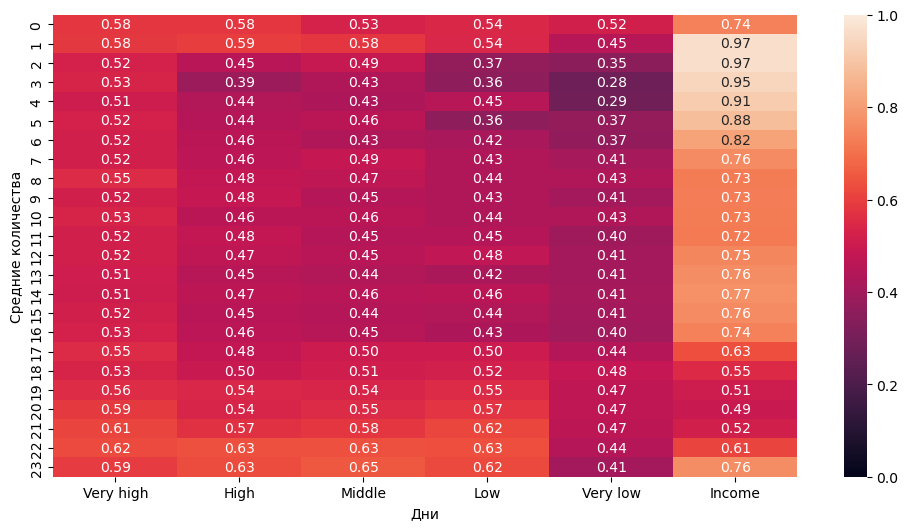

In [ ]:
tr_mcc_codes=pd.read_csv(filepath_or_buffer = "tr_mcc_codes.csv",
           sep = ';')
tr_types=pd.read_csv(filepath_or_buffer = "tr_types.csv",
           sep = ';')
transactions=pd.read_csv(filepath_or_buffer = "transactions.csv", nrows=1000000)
gender_train=pd.read_csv(filepath_or_buffer = "gender_train.csv")


transactions=pd.merge(transactions, gender_train, how='left')
transactions=pd.merge(transactions, tr_mcc_codes, how='inner')
transactions=pd.merge(transactions, tr_types, how='inner')
del gender_train
del tr_mcc_codes
del tr_types
transactions['tr_day'] = transactions['tr_datetime'].str.split().str[0]


transactions['amount_bucket']=pd.qcut(transactions.loc[transactions['amount'] < 0, 'amount'], 5, labels=['Very high', 'High', 'Middle', 'Low', 'Very low'])
transactions['amount_bucket'] = transactions['amount_bucket'].cat.add_categories('Income').fillna('Income')

transactions['tr_hour']=transactions['tr_datetime'].str.split().str[1].str[:2].astype(int)
tr = pd.pivot_table(
    transactions,
    index='tr_hour',
    columns='amount_bucket',
    values='gender'
    
)

plt.figure(figsize=(12,6))
sns.heatmap(tr, annot=True, fmt=".2f", vmin=0, vmax=1)
plt.xlabel('Переводы')
plt.ylabel('Время')
plt.show()


### Task 8.
1. Измените тип поля tr_day на int.
2. Выберите из transactions все MCC коды, которые встретились в выборке более чем 60000 раз.
3. Сгруппируйте отфильтрованный датафрейм по дню и MCC-коду, получая средние значения суммы amount.  
4. Далее отрисуйте зависимость средних сумм (может пригодится метод unstack()) по каждому из MCC-кодов по дням.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) 2 из полученных MCC-кодов связаны с финансовыми институтами
     2) 2 MCC кода, связанные со снятием наличности имеют в целом разные знаки (в одном случае почти везде - траты, в другом - пополнения)
     3) Бакалейные магазины обладают максимальными средними тратами среди выбранных MCC-кодов
     4) Денежные переводы имеют как минимум 3 явных минимума средних
     5) Категория "Звонки с использованием телефонов, считывающих магнитную ленту" имеет визуально очень большую дисперсию. 

    mcc_code                                    mcc_description
0       4814  Звонки с использованием телефонов, считывающих...
1       6011  Финансовые институты — снятие наличности автом...
2       4829                                  Денежные переводы
16      6010   Финансовые институты — снятие наличности вручную
48      5411                  Бакалейные магазины, супермаркеты


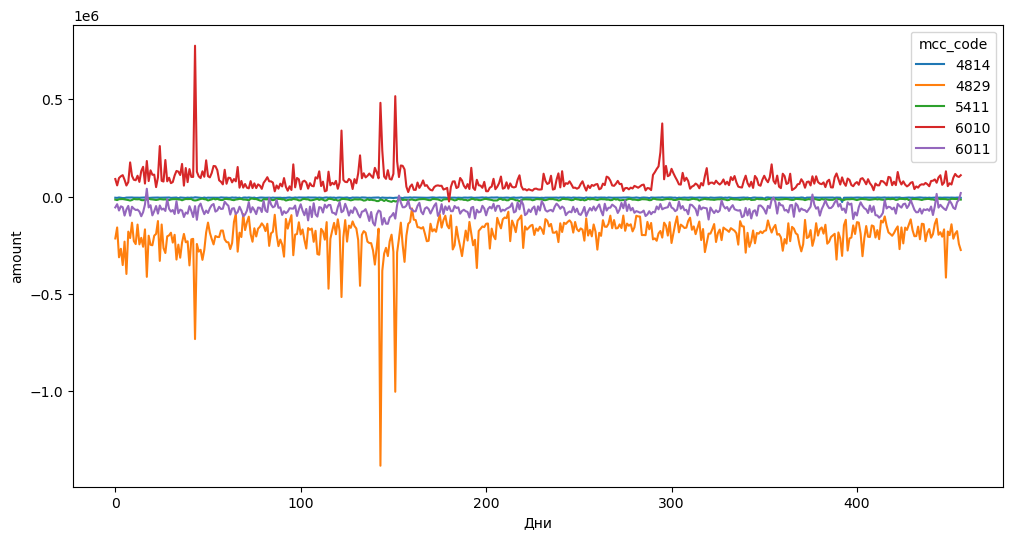

In [12]:
tr_mcc_codes=pd.read_csv(filepath_or_buffer = "tr_mcc_codes.csv",
           sep = ';')
tr_types=pd.read_csv(filepath_or_buffer = "tr_types.csv",
           sep = ';')
transactions=pd.read_csv(filepath_or_buffer = "transactions.csv", nrows=1000000)
gender_train=pd.read_csv(filepath_or_buffer = "gender_train.csv")


transactions=pd.merge(transactions, gender_train, how='left')
transactions=pd.merge(transactions, tr_mcc_codes, how='inner')
transactions=pd.merge(transactions, tr_types, how='inner')
del gender_train
del tr_mcc_codes
del tr_types
transactions['tr_day'] = transactions['tr_datetime'].str.split().str[0]

transactions['tr_day']=transactions['tr_day'].astype('int')

transactions = transactions[transactions['mcc_code'].isin(transactions['mcc_code'].value_counts()[transactions['mcc_code'].value_counts() > 60000].index)]

tr=transactions.groupby(['tr_day', 'mcc_code'])['amount'].mean().unstack()
print(transactions[['mcc_code', 'mcc_description']].drop_duplicates())
tr.plot(figsize=(12,6))
plt.xlabel('Дни')
plt.ylabel('amount')
plt.show()

### Task 9:
Считайте данные из файла 'winemag-data-130k-v2.csv'. 
а) Постройте точечный график (Scatter plot), по оси х отложите points, а по y - price.
б) Постройте график Barplot количества вин по странам.

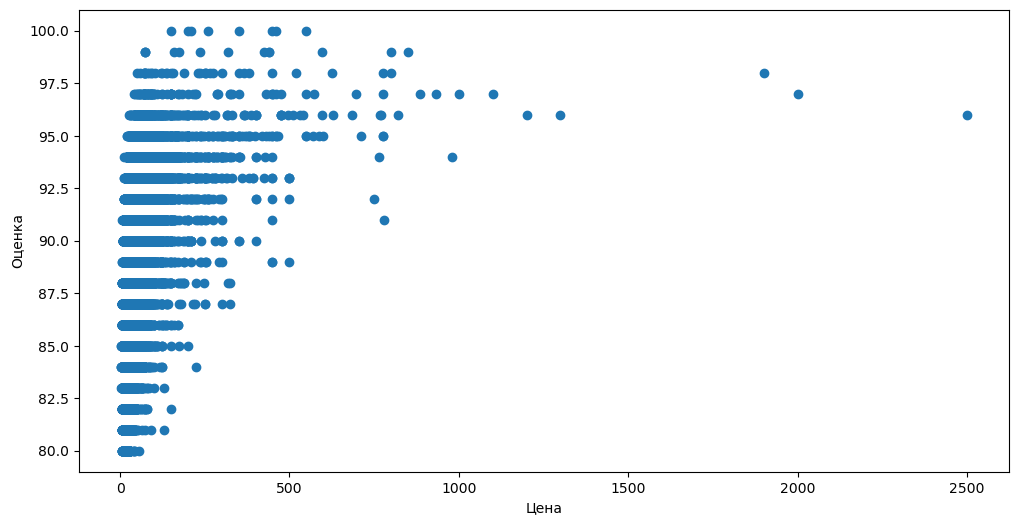

C:\Users\NND01\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


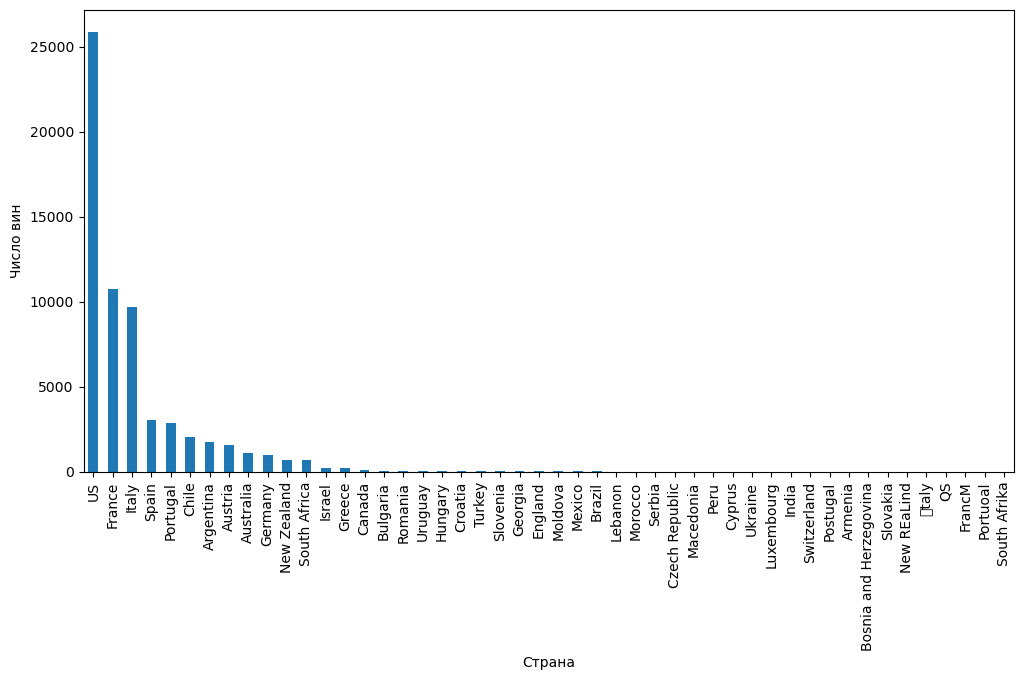

In [19]:
from io import StringIO
import csv

# Вся строка заключена в кавычки, разделитель строк нестандартный. Требуется предобработка)
with open("winemag-data-130k-v2.csv", "r", encoding='utf-8') as f:
    text = f.read()

# Разбитие по разделителю ;;;;
lines = [r.strip() for r in text.split(";;;;") if r.strip()]

# Заголовок
header_line = lines[0]
header = next(csv.reader([header_line], delimiter=","))

explen=len(header)
rows = []
bad = 0

for rec in lines[1:]:
    if rec.startswith('"') and rec.endswith('"'):
        rec = rec[1:-1]

    try:
        rec=rec.replace('""','"')
        row = next(csv.reader([rec], delimiter=",", quotechar='"', doublequote=True))
        if len(row) != explen:
            bad += 1
            continue
        rows.append(row)
        
    except Exception:
        bad += 1

winemag = pd.DataFrame(rows, columns=header)

winemag = winemag.drop(winemag.columns[0], axis=1)
winemag

# преобразование цены в число. Пустота заменяется на Nan
winemag['price'] = pd.to_numeric(winemag['price'], errors='coerce')
winemag['points'] = pd.to_numeric(winemag['points'], errors='coerce')
# очистка NaN
clean = winemag.dropna(subset=['price', 'points'])



plt.figure(figsize=(12,6))
plt.scatter(clean['price'],
            clean['points'])
plt.xlabel('Цена')
plt.ylabel('Оценка')
plt.show()

winemag_country_filter = winemag[
    winemag['country'].str.match(r'^[A-Za-z\s]+$', na=False)
]
country_count = winemag_country_filter['country'].value_counts()

plt.figure(figsize=(12,6))
country_count.plot(kind='bar')
plt.xlabel('Страна')
plt.ylabel('Число вин')

plt.show()